Test `create_gaussian_template` function

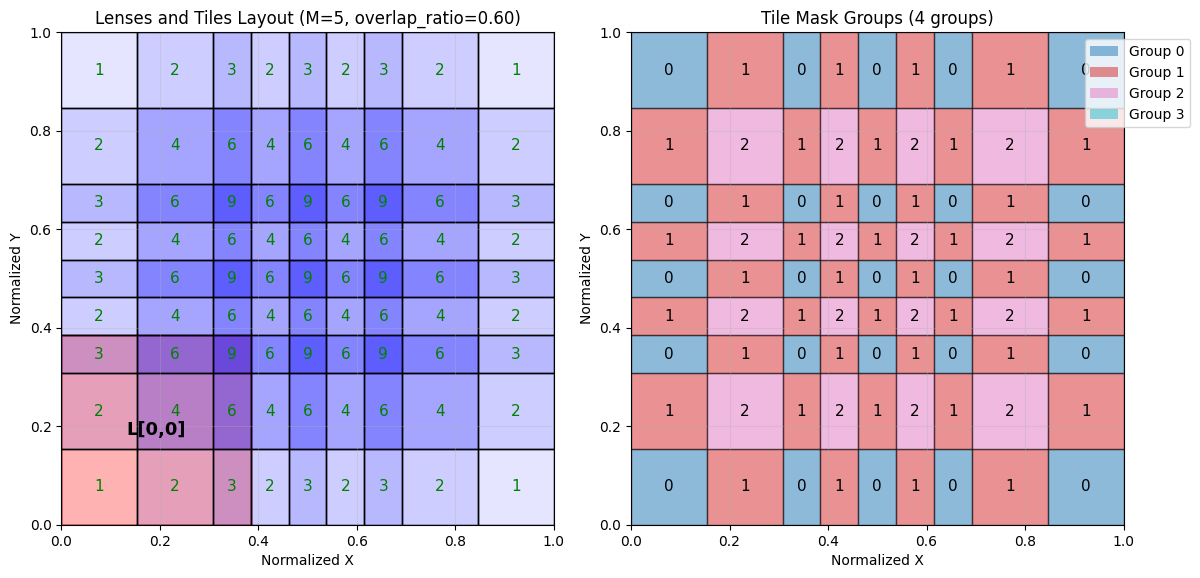


Tile Statistics:
Total tiles: 81
Grid dimensions: 9 x 9
Tiles per group: {0: 25, 1: 40, 2: 16, 3: 0}
Lens contribution distribution: {1: 4, 2: 16, 3: 12, 4: 16, 6: 24, 9: 9}


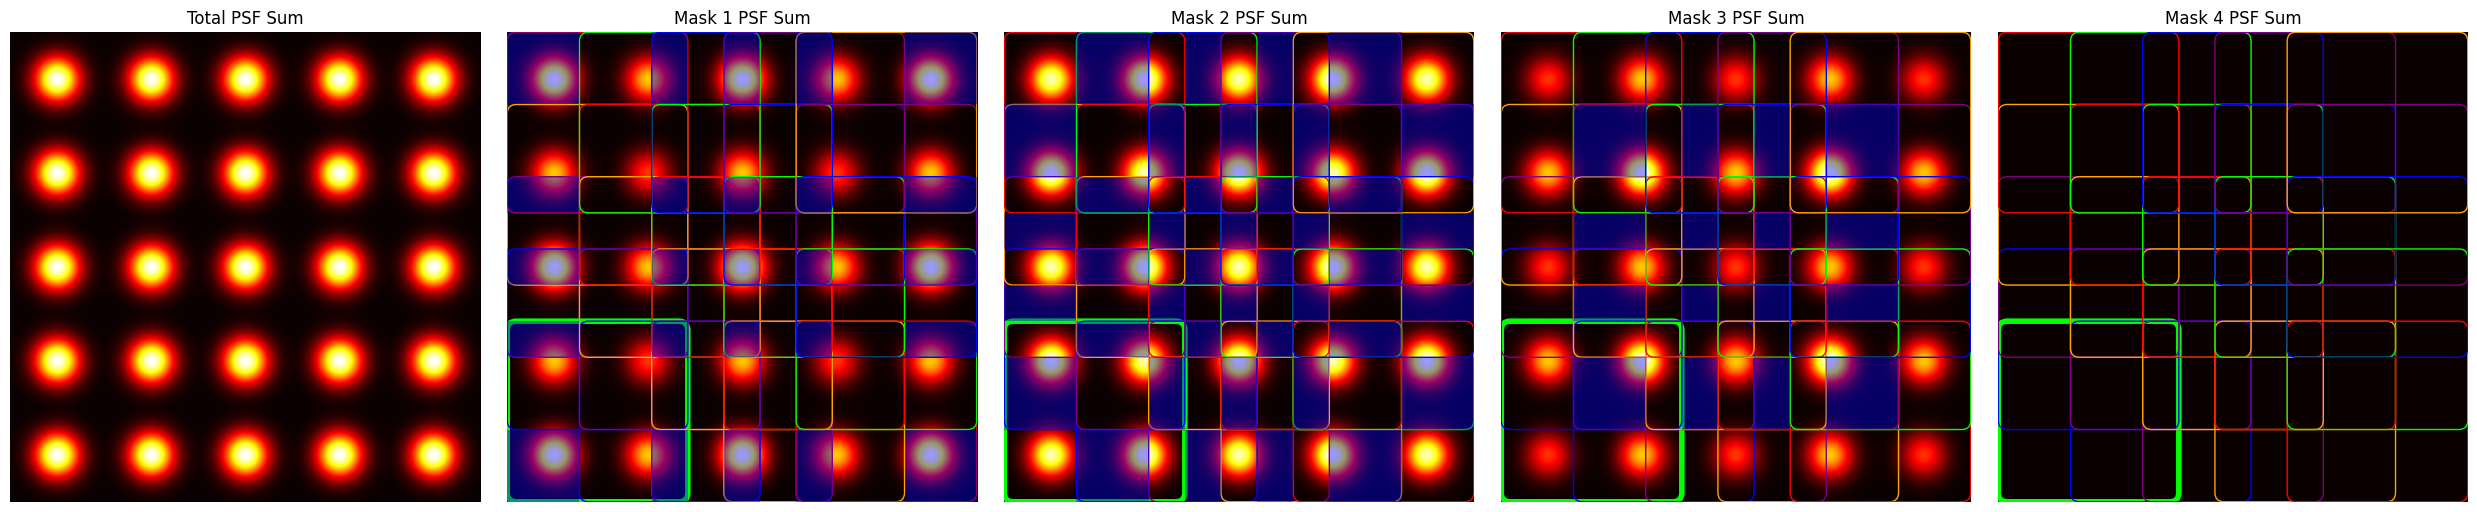

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
import numpy as np
from optics_utils import create_gaussian_template

# Test parameters
N = 1024
L = 1e-3  # 1 mm
focal_length = 0.05  # 50 mm
wavelength = 5e-7  # 500 nm
M = 5
overlap_ratio = 0.6
num_masks = 4

# Call the function
results = create_gaussian_template(
    N, L, focal_length, wavelength, M, overlap_ratio, torch.device('cpu'),
    center_blend = 0, mask_count=num_masks, 
    visualize = True,
    interleaving="coarse1",
    coarse_grid_size = 2
)

total_psfs = results['total_psfs']
mask_psfs = results['mask_psfs']
masks_tiles = results['masks_tiles']

# Visualization
fig, axs = plt.subplots(1, num_masks + 1, figsize=(5 * (num_masks + 1), 5))

# First, plot the total PSF
axs[0].imshow(total_psfs.cpu().numpy(), cmap='hot', origin='lower')
axs[0].set_title('Total PSF Sum')
axs[0].axis('off')

# Compute lens boundaries in pixel coordinates
region_size_px = (1.0 / (M - (M - 1) * overlap_ratio)) * (N - 1)
stride_px = region_size_px * (1 - overlap_ratio)

# For each mask
for mask_id in range(num_masks):
    ax = axs[mask_id + 1]
    
    # Plot PSF sum with colormap
    psf_np = mask_psfs[mask_id].cpu().numpy()
    im = ax.imshow(psf_np, cmap='hot', origin='lower', norm=Normalize(vmin=0, vmax=np.max(psf_np)))
    ax.set_title(f'Mask {mask_id + 1} PSF Sum')
    
    # --- 循环绘制圆角矩形，轮流使用颜色和半透明填充 ---
    # 'red', 'green', 'blue', 'purple', 'orange', 'cyan', 'magenta', 'yellow'
    edge_colors = ['#FF0000', '#00FF00', '#0000FF', '#800080', '#FFA500'] 
    color_index = 0
    for i in range(M):
        color_index += 1  
        for j in range(M):
            if i==0 and j==0:
                linewidth = 4
            else:
                linewidth = 1
            x = i * stride_px
            y = j * stride_px
            current_edge_color = edge_colors[color_index % len(edge_colors)]
            color_index += 1     
            unit = patches.FancyBboxPatch(
                (x, y), 
                region_size_px, 
                region_size_px,
                boxstyle=f"round,pad=0,rounding_size={region_size_px/20}", # 调整圆角大小
                linewidth=linewidth, 
                edgecolor=current_edge_color,
                facecolor='none', 
                linestyle='-' # 可以改为实线，或者保持 '--' 虚线
            )
            ax.add_patch(unit)   
            
    # Semi-transparent fill for mask tiles
    for tile in masks_tiles[mask_id]:  # Assuming masks_tiles from function, but need to extract it
        # Note: masks_tiles is local in function, so for real code, return it or compute similarly
        x_start_px = tile['x_start_norm'] * (N - 1)
        y_start_px = tile['y_start_norm'] * (N - 1)
        width_px = (tile['x_end_norm'] - tile['x_start_norm']) * (N - 1)
        height_px = (tile['y_end_norm'] - tile['y_start_norm']) * (N - 1)
        rect = patches.Rectangle((x_start_px, y_start_px), width_px, height_px,
                                 linewidth=0, facecolor='blue', alpha=0.4)
        ax.add_patch(rect)
    
    ax.axis('off')

plt.tight_layout()
plt.show()